In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()

while ROOT.name != "langchain" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

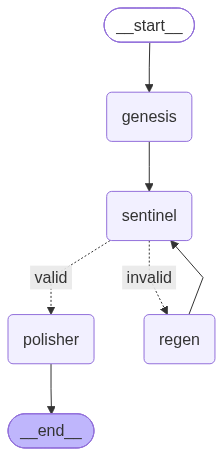

In [12]:
from typing import Annotated
from typing_extensions import TypedDict

from src.node1.node_1 import genesis
from src.node2.node_2 import sentinel
from src.node3.node_3 import regen
from src.node4.node_4 import polisher

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

class DiagramState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    user_input: str
    generated_json: str
    is_valid : bool
    validated_json: str
    corrected_json: str


# build graph
graph = StateGraph(DiagramState)

graph.add_node("genesis", genesis)
graph.add_node("sentinel", sentinel)
graph.add_node("polisher", polisher)
graph.add_node("regen", regen)

# connect nodes
graph.set_entry_point("genesis")
graph.add_edge("genesis", "sentinel")
graph.add_edge("regen", "sentinel")

graph.add_conditional_edges("sentinel",
    lambda state: "valid" if state.get("is_valid") else "invalid",
    {
        "valid": "polisher",
        "invalid": "regen",
    },)

graph.add_edge("polisher", END)

app = graph.compile()

# initial_state = DiagramState(user_input="Draw me a network diagram")
# final_state = app.invoke(initial_state)

# print(final_state)

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("error" , e)
    # This requires some extra dependencies and is optional
    pass